# OpenMC transport model for a concentric annular fuel model (i.e like Missouri Research Reactor)

This notebook mirrors the workflow in frm2_nat.ipynb, but replaces the involute fuel plates with a concentric annular layout. A critical configuration with natural uranium is modeled with openmc and then ran to find K_eff as well as flux, fission and entropy tallies.

## Models

The reference case below uses {ring_count} concentric fuel annuli with {ring_thickness} fuel thickness.

In [2]:
import importlib
import os
from pathlib import Path

import matplotlib.pyplot as plt
import openmc

import concentric_fuel
import reactor_geometry
import build_simulation
from ploting import plot_reactor_preview, resolve_openmc_exec, show_statepoint_diagnostics

importlib.reload(concentric_fuel)
importlib.reload(reactor_geometry)
importlib.reload(build_simulation)

from concentric_fuel import (
    ConcentricElementParameters,
    build_parameter_report,
    quick_layout_plot,
    validate_parameters,
 )
from reactor_geometry import ReactorTankParameters, validate_reactor_tanks

CONCENTRIC_FUEL_PARAMETERS = ConcentricElementParameters(
    ring_count=7,
    ring_thickness_cm=0.5,
    coolant_gap_cm=7.0,
    inner_radius_cm=4.5,
    outer_radius_cm=50.0,
    control_rod_radius_cm=4.0,
    h_active_cm=300.0,
    lower_plenum_cm=50.0,
    upper_plenum_cm=50.0,
    fuel_density_g_per_cm3=12.2,
    fuel_enrichment_wt_pct=0.7198,
 )

REACTOR_TANK_PARAMETERS = ReactorTankParameters(
    d2o_tank_radius_cm=250.0,
    h2o_tank_radius_cm=500.0,
    h_d2o_tank_cm=600.0,
    h_h2o_tank_cm=1000.0,
 )

validate_parameters(CONCENTRIC_FUEL_PARAMETERS)
validate_reactor_tanks(CONCENTRIC_FUEL_PARAMETERS, REACTOR_TANK_PARAMETERS)

GEOMETRY = build_parameter_report(CONCENTRIC_FUEL_PARAMETERS)
GEOMETRY.update(REACTOR_TANK_PARAMETERS.to_geometry_dict())

GLOBAL_MESH_SHAPE = (160, 160)
FUEL_MESH_SHAPE = (220, 220)
DEFAULT_OPENMC_THREADS = os.cpu_count() or 1
OPENMC_THREADS = int(os.environ.get("OPENMC_THREADS", DEFAULT_OPENMC_THREADS))
OPENMC_EXEC = resolve_openmc_exec()

RUN_DIR = Path("build") / "concentric"
RUN_DIR.mkdir(parents=True, exist_ok=True)

GEOMETRY_REPORT = {
    "fuel_element": build_parameter_report(CONCENTRIC_FUEL_PARAMETERS),
    "reactor_tanks": REACTOR_TANK_PARAMETERS.to_geometry_dict(),
    "openmc_threads": OPENMC_THREADS,
    "openmc_exec": OPENMC_EXEC,
}
GEOMETRY_REPORT

{'fuel_element': {'ring_count': 7,
  'ring_thickness_cm': 0.5,
  'coolant_gap_cm': 7.0,
  'inner_radius_cm': 4.5,
  'outer_radius_cm': 50.0,
  'control_rod_radius_cm': 4.0,
  'h_active_cm': 300.0,
  'lower_plenum_cm': 50.0,
  'upper_plenum_cm': 50.0,
  'fuel_density_g_per_cm3': 12.2,
  'fuel_enrichment_wt_pct': 0.7198,
  'radial_span_cm': 45.5,
  'edge_gap_cm': 0.0,
  'h_total_cm': 400.0,
  'first_ring_inner_radius_cm': 4.5,
  'last_ring_outer_radius_cm': 50.0,
  'uranium_area_fraction': 0.07692307692307693,
  'uranium_volume_cm3': 179777.6396016759,
  'uranium_mass_kg': 2193.287203140446},
 'reactor_tanks': {'d2o_tank_radius_cm': 250.0,
  'h2o_tank_radius_cm': 500.0,
  'h_d2o_tank_cm': 600.0,
  'h_h2o_tank_cm': 1000.0,
  'h_total_cm': 1000.0},
 'openmc_threads': 19,
 'openmc_exec': '/home/pablo/miniconda3/envs/openmc/bin/openmc'}

{'ring_count': 7, 'ring_thickness_cm': 0.5, 'coolant_gap_cm': 7.0, 'inner_radius_cm': 4.5, 'outer_radius_cm': 50.0, 'control_rod_radius_cm': 4.0, 'h_active_cm': 300.0, 'lower_plenum_cm': 50.0, 'upper_plenum_cm': 50.0, 'fuel_density_g_per_cm3': 12.2, 'fuel_enrichment_wt_pct': 0.7198, 'radial_span_cm': 45.5, 'edge_gap_cm': 0.0, 'h_total_cm': 400.0, 'first_ring_inner_radius_cm': 4.5, 'last_ring_outer_radius_cm': 50.0, 'uranium_area_fraction': 0.07692307692307693, 'uranium_volume_cm3': 179777.6396016759, 'uranium_mass_kg': 2193.287203140446}


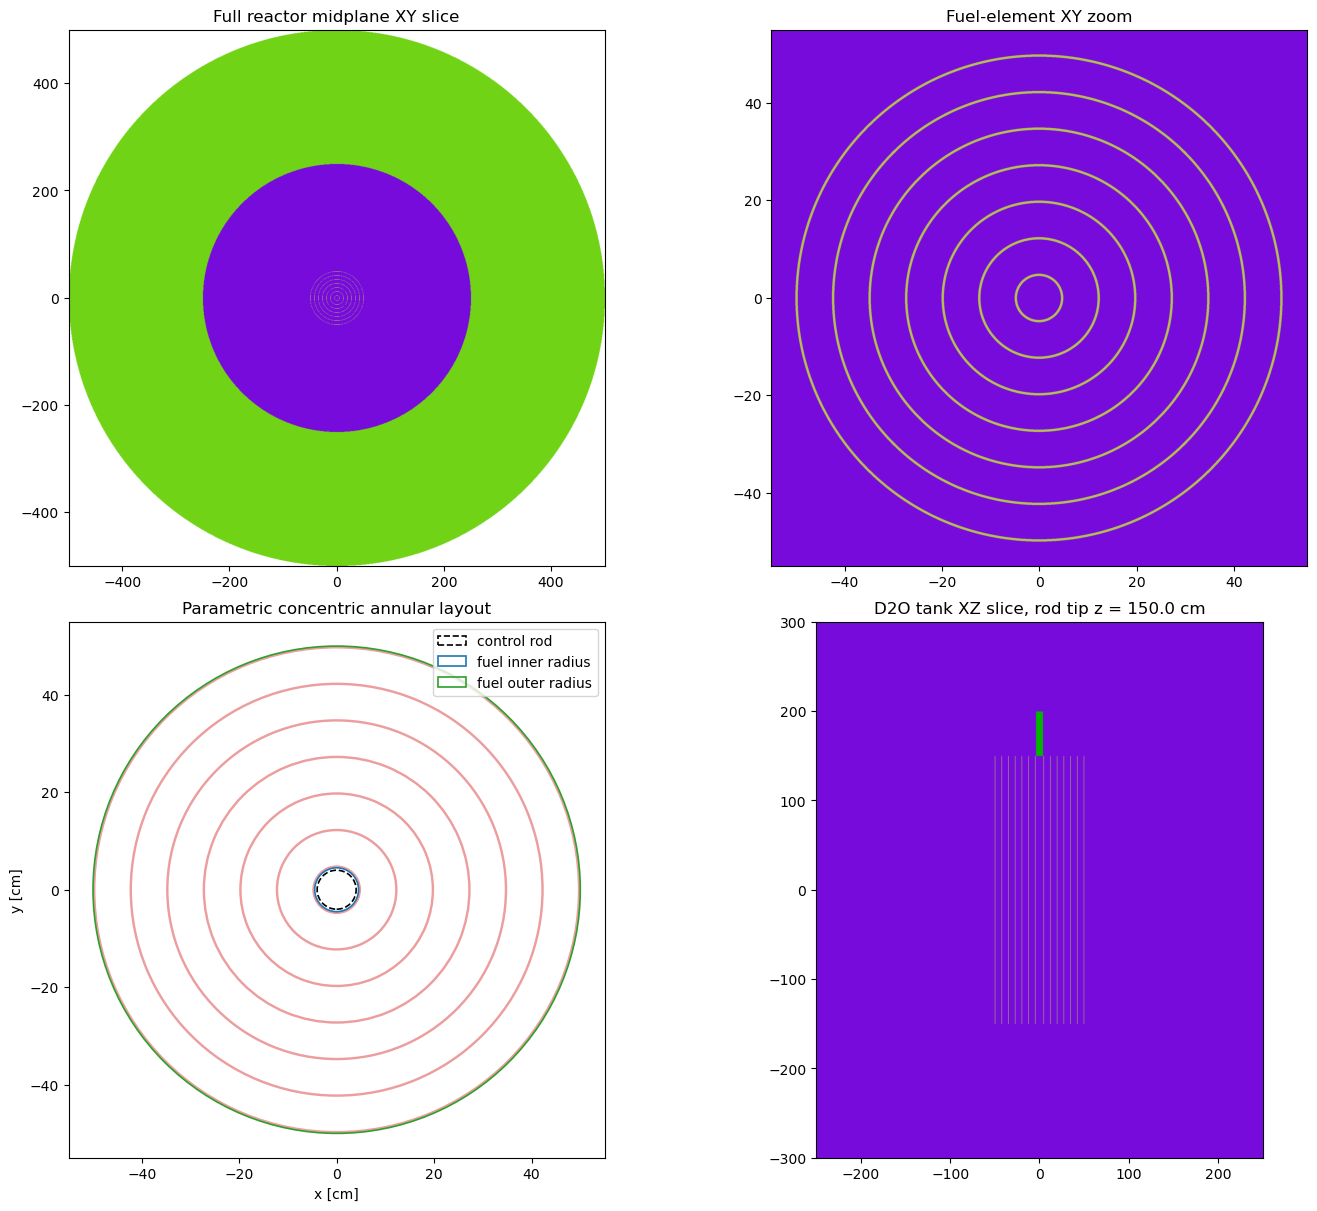

In [3]:
preview_model, preview_metadata = build_simulation.build_eigenvalue_model(
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
    rod_insertion=0.0,
    particles=2000,
    batches=1,
    inactive=0,
    global_mesh_shape=None,
    fuel_mesh_shape=None,
)

plot_reactor_preview(
    preview_model,
    preview_metadata,
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
    quick_layout_plot=quick_layout_plot,
    layout_title="Parametric concentric annular layout",
)
print(build_parameter_report(CONCENTRIC_FUEL_PARAMETERS))
plt.show()

In [ ]:
cross_sections = openmc.config.get("cross_sections")

if cross_sections:
    reference_insertion = 0.0
    reference_model, reference_metadata = build_simulation.build_eigenvalue_model(
        CONCENTRIC_FUEL_PARAMETERS,
        REACTOR_TANK_PARAMETERS,
        rod_insertion=reference_insertion,
        particles=20000,
        batches=50,
        inactive=10,
        global_mesh_shape=GLOBAL_MESH_SHAPE,
        fuel_mesh_shape=FUEL_MESH_SHAPE,
    )
    statepoint_path = reference_model.run(
        cwd=RUN_DIR,
        threads=OPENMC_THREADS,
        openmc_exec=OPENMC_EXEC,
        export_model_xml=True,
    )
    print(f"OpenMC run finished: {statepoint_path}")
    print(f"model.xml written to {RUN_DIR / 'model.xml'}")
    if reference_metadata["tally_names"]:
        print(f"Tallies recorded: {reference_metadata['tally_names']}")
    else:
        print("No mesh tallies were attached to this run, so this is a faster k_eff-only calculation.")
else:
    statepoint_path = None
    reference_metadata = None
    print(
        "Set openmc.config['cross_sections'] or OPENMC_CROSS_SECTIONS before running eigenvalue calculations."
    )

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

# Run Diagnostics and Tallies

This cell now reports the Shannon entropy history for the fission source so you can judge whether the inactive batches were sufficient before trusting the final k_eff.

The mesh plotting section still stays dormant unless the run above was executed with mesh tallies enabled by passing a non-None mesh shape to build_model.

k_eff = 1.001090 +/- 0.000957
reactivity = 108.9 pcm
entropy mesh shape = (7, 7, 21)
final Shannon entropy = 9.766689
entropy spread over last 10 active batches = 0.012363


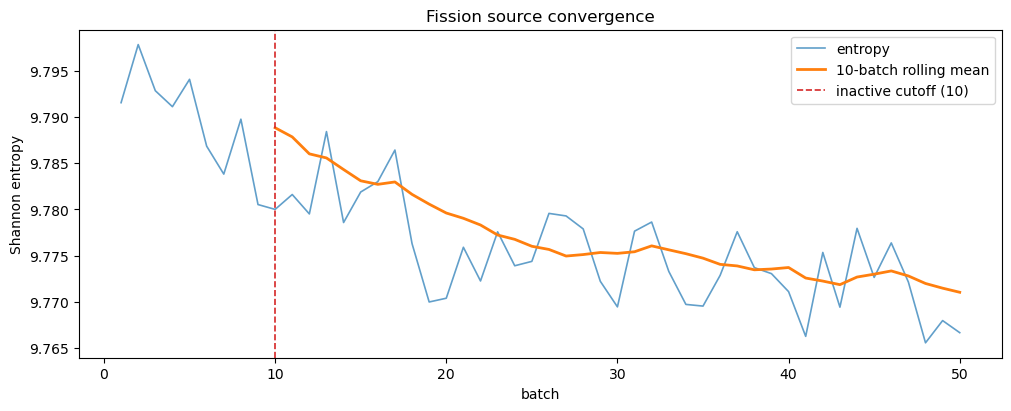

/home/pablo/modelica/ReactorKineticsLab/openmc/ploting.py:325: RuntimeWarning: invalid value encountered in divide
  flux_rel_err = np.ma.masked_where((flux <= 0.0) | ~np.isfinite(flux_std), flux_std / flux)
/home/pablo/modelica/ReactorKineticsLab/openmc/ploting.py:326: RuntimeWarning: invalid value encountered in divide
  fission_rel_err = np.ma.masked_where((fission <= 0.0) | ~np.isfinite(fission_std), fission_std / fission)


global-mesh histories per bin: 31.250
flux nonzero fraction: 0.316
fission nonzero fraction: 0.027


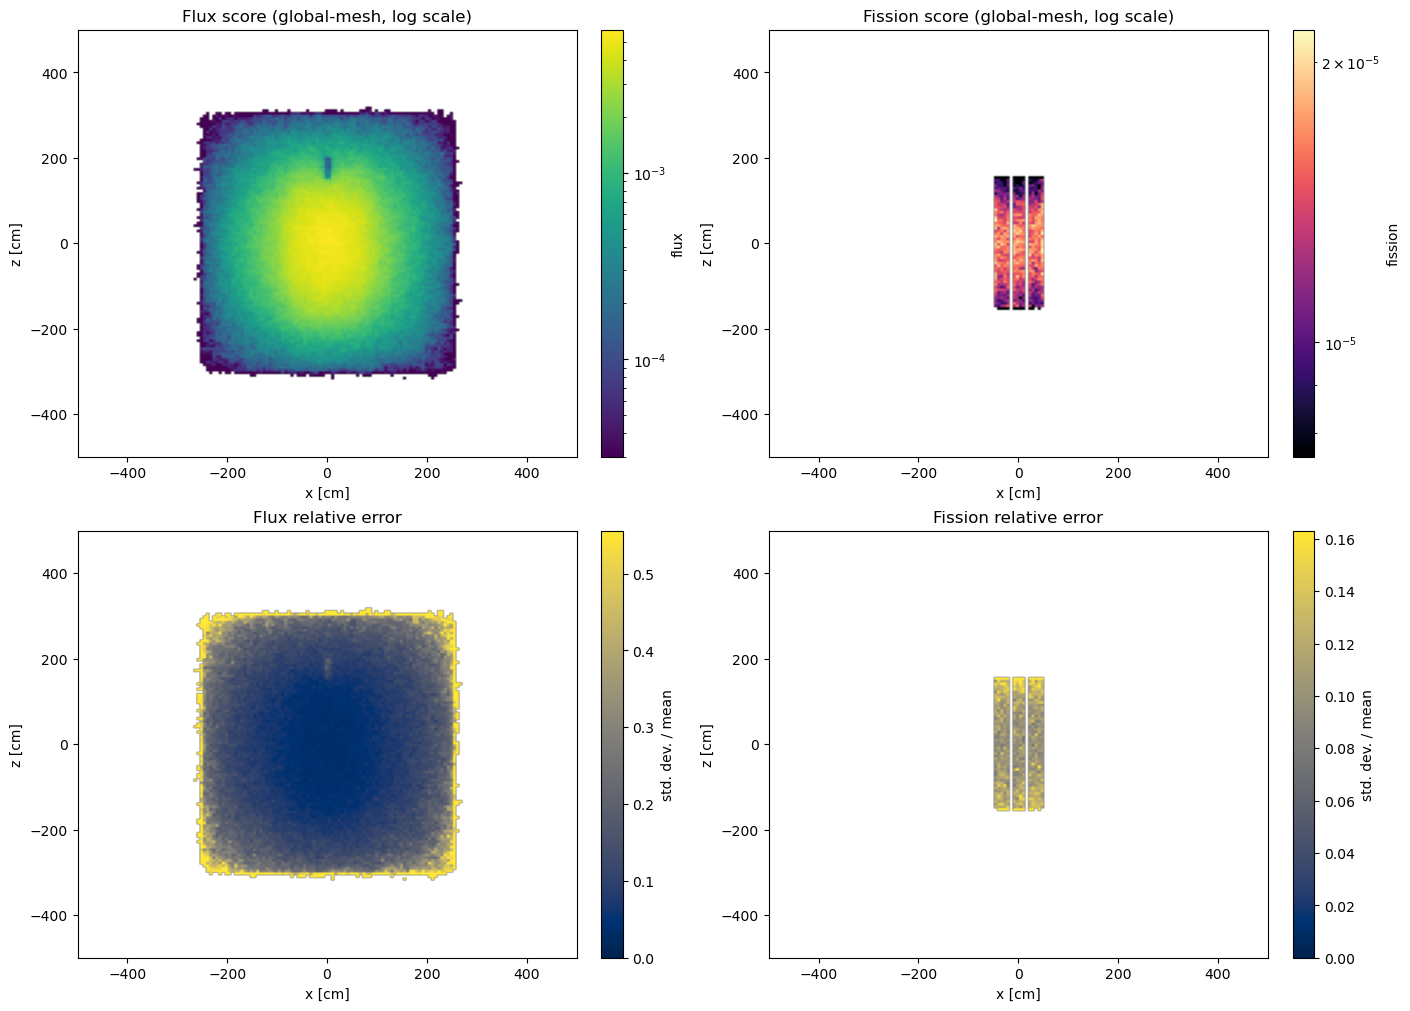

In [5]:
show_statepoint_diagnostics(
    statepoint_path,
    reference_metadata,
    CONCENTRIC_FUEL_PARAMETERS,
    REACTOR_TANK_PARAMETERS,
)